In [ ]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sc_toolbox as sct

[rank: 0] Global seed set to 0


In [ ]:
mpl.rcParams["figure.figsize"] = (5, 5)

In [ ]:
plt.rcParams['pdf.fonttype'] = 42

In [ ]:
adata = sc.read('../data/cellcharter_dmg_FINAL.h5ad')
adata

AnnData object with n_obs × n_vars = 26552 × 990
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA_MembraneStain_B2M', 'Max.rRNA_MembraneStain_B2M', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'sample', 'sample2', 'orig.ident', 'nCount_Nanostring', 'nFeature_Nanostring', 'Mean.rRNA_CD298_B2M', 'Max.rRNA_CD298_B2M', 'Slide_name', 'Run_name', 'ISH.concentration', 'Beta', 'tissue', 'Run_Slide_name', 'slide_ID_numeric', 'Run_Tissue_name', 'log10totalcounts', 'IFcolor', 'nb_clus', 'leiden_clus', 'id', 'FOV', 'PMCID', 'Replicate', 'ID_R', 'n_counts', '_scvi_batch', '_scvi_labels', 'cluster_cellcharter', 'tangram_prediction', 'leiden', 'cellcharter_6', 'cellcharter_9', 'cellcharter_12'
    var: 'n_counts'
    uns: 'PMCID_colors', '_cellcharter', '_scvi_manager_uuid', '_scvi_uuid', 'cluster_cellcharter_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'spatial

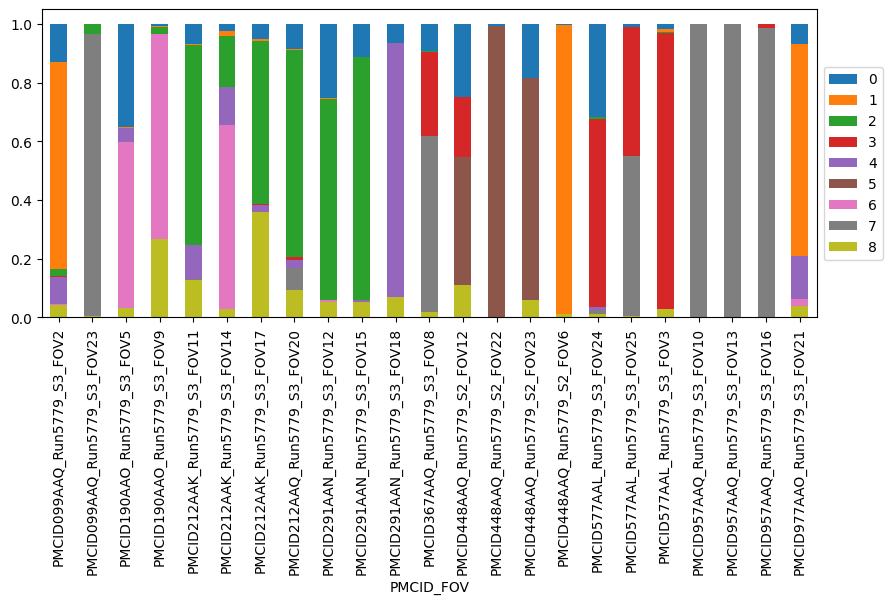

In [ ]:
adata.obs['PMCID_FOV'] = adata.obs.PMCID.astype(str) + '_' + adata.obs.FOV.astype(str)
adata.obs['PMCID_FOV'] = adata.obs['PMCID_FOV'].astype('category')
cc.pl.proportion(
    adata,
    group_key='PMCID_FOV',
    label_key='cellcharter_9',
    figsize=(10, 4),
    rotation_xlabel=90,
        save='figures/cellcharter_9niches_cosmx.pdf'
)

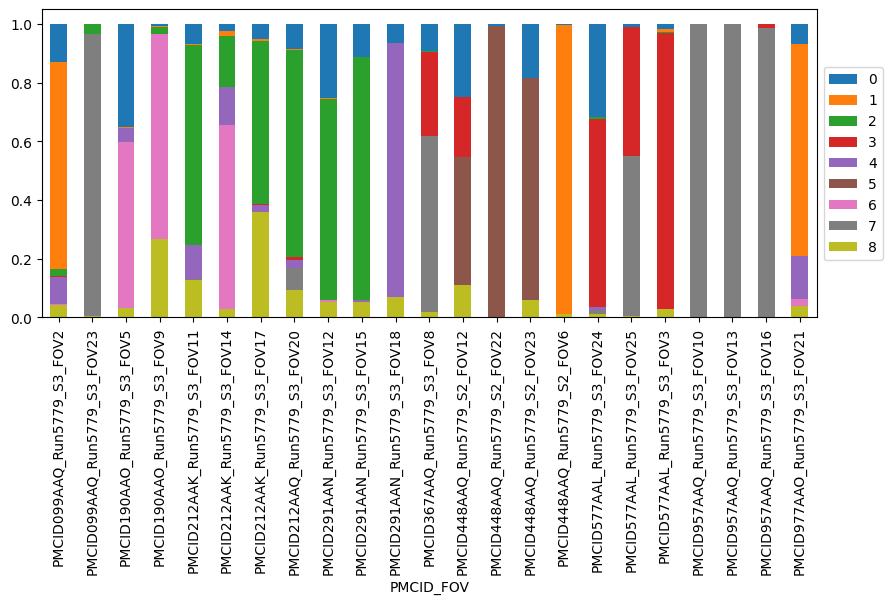

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from cellcharter.pl import proportion

# Set the pdf.fonttype to 42 to embed fonts as Type 42 (TrueType)
mpl.rcParams['pdf.fonttype'] = 42

# Create the plot
proportion(adata,
    group_key='PMCID_FOV',
    label_key='cellcharter_9',
    figsize=(10, 4),
    rotation_xlabel=90,
           save=None)

# Save the plot as PDF with embedded fonts
plt.savefig('figures/cellcharter_9niches_cosmx.pdf', format='pdf', bbox_inches='tight')

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:757: RuntimeWarning: invalid value encountered in power
  size = frac**size_exponent


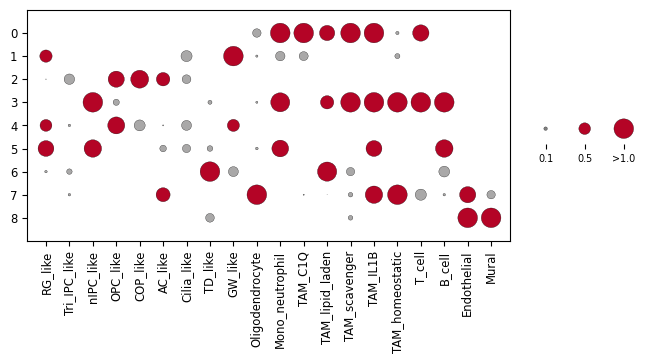

In [ ]:
# cc.gr.enrichment(adata, group_key='tangram_prediction', label_key='cellcharter_9', observed_expected=True)
cc.pl.enrichment(
    adata,
    group_key='tangram_prediction',
    label_key='cellcharter_9',
    cluster_labels=False,
    figsize=(8, 3),
    size_threshold=1,
    color_threshold=0.5,
    save='figures/enrichment_cellcharter_celltype_vs_niche.pdf'
)